In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import statistics as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("C:/Users/maan/Desktop/covid_19_clean_complete.csv")
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [19]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [20]:
df.dropna(inplace=True)

In [21]:
df.isnull().sum()

Province/State    0
Country/Region    0
Lat               0
Long              0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
dtype: int64

In [22]:
df['Date'] = pd.to_datetime(df['Date'])

In [23]:
df.fillna(0, inplace=True)

In [24]:
df.drop_duplicates(inplace=True)

In [25]:
global_daily = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

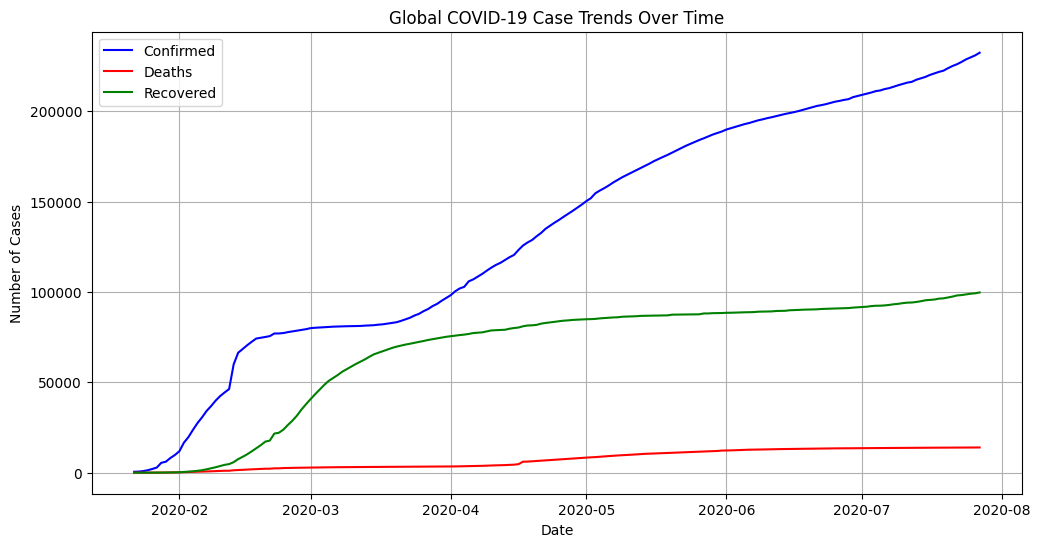

In [26]:
plt.figure(figsize=(12, 6))

plt.plot(global_daily['Date'], global_daily['Confirmed'], label='Confirmed', color='blue')
plt.plot(global_daily['Date'], global_daily['Deaths'], label='Deaths', color='red')
plt.plot(global_daily['Date'], global_daily['Recovered'], label='Recovered', color='green')

plt.title("Global COVID-19 Case Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
top_countries = (
    df.groupby('Country/Region')['Confirmed']
    .max()
    .sort_values(ascending=False)
    .head(10)
    .index
)

In [28]:
heatmap_data = df[df['Country/Region'].isin(top_countries)]

pivot_table = heatmap_data.pivot_table(
    values='Confirmed',
    index='Country/Region',
    columns='Date',
    aggfunc='sum'
)

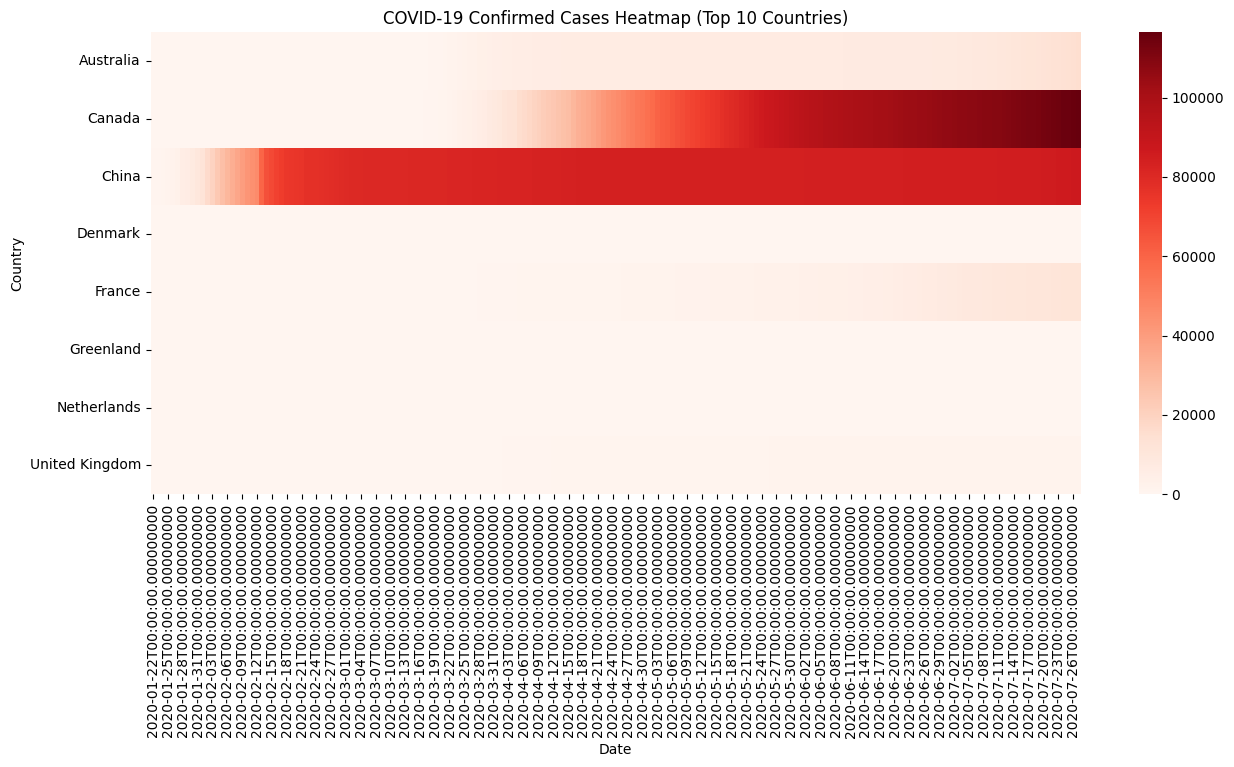

In [29]:
plt.figure(figsize=(15, 6))
sns.heatmap(pivot_table, cmap="Reds")

plt.title("COVID-19 Confirmed Cases Heatmap (Top 10 Countries)")
plt.xlabel("Date")
plt.ylabel("Country")

plt.show()